<div align="center">

# <span style="color:#2E86C1;"> Tutorial 1: Optimization Basics - A Computational Toolkit</span>

**Author:** [<span style="color:#8E44AD;">Dr. D Bhanu Prakash</span>](https://dbhanuprakash233.github.io)

<img src="https://github.com/dbhanuprakash233/SSSIHL_DBP/blob/main/assets/SssihlLogo.png?raw=true" alt="University Logo" width="80"/>

**<span style="color:#16A085;">Sri Sathya Sai Institute of Higher Learning</span>**  
<span style="color:#5D6D7E;">Prasanthi Nilayam - 515 134, Andhra Pradesh, India.</span>

**Course:** <span style="color:#D35400;">Optimization Techniques for Machine Learning</span>  
**Course Code:** <span style="color:#1ABC9C;">UMAM-502</span>

</div>


**Prerequisites:** Linear algebra (vectors, matrices), single/multivariable calculus, basic Python

## Learning objectives

By the end of this notebook you should be able to:

1. Compute eigenvalues/eigenvectors both "by hand" (via an algorithm you code yourself) and using library routines, and explain *why* the algorithm works.
2. Compute derivatives, gradients, Jacobians, and Hessians numerically, symbolically, and (conceptually) via automatic differentiation.
3. Use eigen-structure of the Hessian to classify critical points (min / max / saddle) and to reason about convexity.
4. Refactor procedural code into a clean, reusable **object-oriented** toolkit - Optional.

> **How to use this notebook:** Read the theory in each markdown cell, then run the code cell(s) that follow. Cells build on each other, so run them in order the first time through.



## 0. Setup

We will use:
- `numpy` for numerical linear algebra
- `scipy.optimize` as a "ground truth" to check our from-scratch implementations against
- `sympy` for symbolic differentiation
- `matplotlib` for visualizing convergence and geometry


In [1]:

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy import optimize as scipy_optimize

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True



## 1. Eigenvalues and Eigenvectors

### 1.1 Why optimization courses care about eigenvalues

For a twice-differentiable function $f:\mathbb{R}^n \to \mathbb{R}$, the local behaviour near a critical point $\mathbf{x}^*$ (where $\nabla f(\mathbf{x}^*) = \mathbf{0}$) is governed by the **Hessian** $H = \nabla^2 f(\mathbf{x}^*)$:

- If all eigenvalues of $H$ are **positive**, $\mathbf{x}^*$ is a local **minimum**.
- If all eigenvalues are **negative**, $\mathbf{x}^*$ is a local **maximum**.
- If eigenvalues have **mixed signs**, $\mathbf{x}^*$ is a **saddle point**.
- The **ratio** of the largest to smallest eigenvalue (the *condition number*) tells us how "stretched" the bowl around the minimum is — and directly controls how fast gradient descent converges.

So before we optimize anything, we need solid tools for eigenvalues/eigenvectors.

### 1.2 Definition

For a square matrix $A \in \mathbb{R}^{n\times n}$, a nonzero vector $\mathbf{v}$ and scalar $\lambda$ satisfying

$$A\mathbf{v} = \lambda \mathbf{v}$$

are called an **eigenvector** and its corresponding **eigenvalue**. Geometrically: $A$ only *stretches/shrinks* $\mathbf{v}$ (by factor $\lambda$) without rotating it off its own line.


In [2]:

# A small symmetric matrix (Hessians in optimization are always symmetric)
A = np.array([[4.0, 1.0],
              [1.0, 3.0]])

eigvals, eigvecs = np.linalg.eig(A)
print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)

# Sanity check: A v = lambda v  for each eigenpair
for i in range(len(eigvals)):
    lhs = A @ eigvecs[:, i]
    rhs = eigvals[i] * eigvecs[:, i]
    print(f"lambda_{i} = {eigvals[i]:.4f}  ->  ||Av - lambda v|| = {np.linalg.norm(lhs - rhs):.2e}")

Eigenvalues: [4.618 2.382]
Eigenvectors (columns):
 [[ 0.8507 -0.5257]
 [ 0.5257  0.8507]]
lambda_0 = 4.6180  ->  ||Av - lambda v|| = 0.00e+00
lambda_1 = 2.3820  ->  ||Av - lambda v|| = 2.22e-16



### 1.3 Implementing the Power Iteration method from scratch

`np.linalg.eig` is a black box (it uses the QR algorithm internally). To really understand eigenvectors, let's implement **power iteration**, the simplest algorithm that finds the eigenvector associated with the **largest-magnitude eigenvalue**.

**Idea:** Repeatedly apply $A$ to a random vector and renormalize. Any starting vector has *some* component along the dominant eigenvector; repeated multiplication by $A$ amplifies that component relative to the others because $\lambda_{\max}$ dominates geometrically.

$$\mathbf{v}_{k+1} = \frac{A\mathbf{v}_k}{\|A\mathbf{v}_k\|}, \qquad \lambda_{\max} \approx \mathbf{v}_k^\top A \mathbf{v}_k \text{ (Rayleigh quotient)}$$


Power iteration eigenvalue : 4.618033988749895
Power iteration eigenvector: [0.8507 0.5257]
numpy dominant eigenvalue  : 4.618033988749895


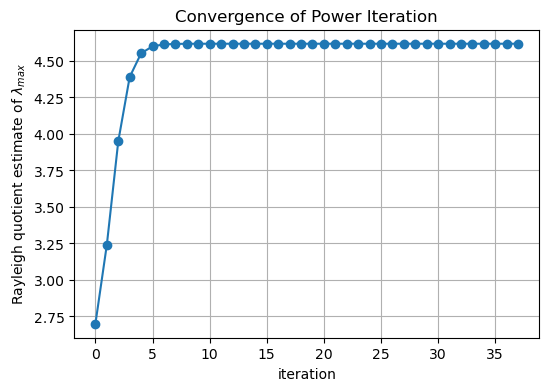

In [3]:

def power_iteration(A, num_iter=100, tol=1e-10, seed=0):
    '''Find the dominant eigenvalue/eigenvector of a square matrix A.

    Parameters
    ----------
    A : (n, n) ndarray
    num_iter : maximum number of iterations
    tol : stop early if the eigenvector estimate stops changing

    Returns
    -------
    eigenvalue : float
    eigenvector : (n,) ndarray, unit norm
    history : list of Rayleigh-quotient estimates (for convergence plotting)
    '''
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    v = rng.standard_normal(n)
    v = v / np.linalg.norm(v)

    history = []
    for _ in range(num_iter):
        v_new = A @ v
        v_new = v_new / np.linalg.norm(v_new)
        lam = v_new @ A @ v_new          # Rayleigh quotient
        history.append(lam)
        if np.linalg.norm(v_new - v) < tol:
            v = v_new
            break
        v = v_new
    return lam, v, history


lam_pow, v_pow, hist = power_iteration(A)
print("Power iteration eigenvalue :", lam_pow)
print("Power iteration eigenvector:", v_pow)
print("numpy dominant eigenvalue  :", eigvals[np.argmax(np.abs(eigvals))])

plt.plot(hist, marker='o')
plt.xlabel("iteration")
plt.ylabel("Rayleigh quotient estimate of $\\lambda_{max}$")
plt.title("Convergence of Power Iteration")
plt.show()



**Note:** eigenvectors are only defined up to sign (and scale, before normalizing) — so `v_pow` may point in the opposite direction to numpy's eigenvector. That's still mathematically correct: if $A\mathbf v=\lambda \mathbf v$ then $A(-\mathbf v)=\lambda(-\mathbf v)$ too.

### 1.4 Symmetric matrices and quadratic forms

Because Hessians are symmetric, it's worth seeing directly how eigenvectors describe the *shape* of a quadratic bowl $f(\mathbf{x}) = \mathbf{x}^\top A \mathbf{x}$.


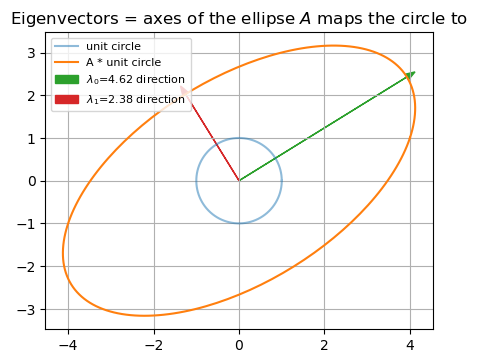

In [4]:

# Visualize how A stretches the unit circle along its eigenvector directions
theta = np.linspace(0, 2*np.pi, 200)
circle = np.vstack([np.cos(theta), np.sin(theta)])
transformed = A @ circle

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(circle[0], circle[1], label="unit circle", alpha=0.5)
ax.plot(transformed[0], transformed[1], label="A * unit circle")

for i in range(2):
    vec = eigvecs[:, i] * eigvals[i]
    ax.arrow(0, 0, vec[0], vec[1], head_width=0.15, color=f"C{i+2}",
              label=f"$\\lambda_{i}$={eigvals[i]:.2f} direction")

ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.set_title("Eigenvectors = axes of the ellipse $A$ maps the circle to")
plt.show()



## 2. Derivatives: Numerical, Symbolic, and Automatic

Optimization algorithms need $\nabla f$ (gradient) and often $\nabla^2 f$ (Hessian). There are three ways to obtain them in practice:

| Method | How it works | Pros | Cons |
|---|---|---|---|
| **Numerical (finite differences)** | Approximate $f'(x) \approx \frac{f(x+h)-f(x-h)}{2h}$ | Works for any black-box $f$ | Approximate, sensitive to step size $h$, slow in high dimensions |
| **Symbolic** | Manipulate the algebraic expression (e.g. with `sympy`) | Exact | Can "explode" in size; needs closed-form $f$ |
| **Automatic differentiation (AD)** | Decompose $f$ into elementary ops and apply the chain rule mechanically at each step | Exact *and* efficient | Needs a supporting framework (PyTorch/JAX); here we build a toy version |

### 2.1 Numerical differentiation


In [5]:

def numerical_gradient(f, x, h=1e-5):
    '''Central-difference gradient of scalar function f: R^n -> R at point x.'''
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        e = np.zeros_like(x)
        e[i] = h
        grad[i] = (f(x + e) - f(x - e)) / (2 * h)
    return grad


def numerical_hessian(f, x, h=1e-4):
    '''Central-difference Hessian of scalar function f: R^n -> R at point x.'''
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei, ej = np.zeros(n), np.zeros(n)
            ei[i], ej[j] = h, h
            H[i, j] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h**2)
    return H


# Test function: f(x, y) = x^2 + 3xy + 4y^2   (a simple convex quadratic bowl)
def f_quad(x):
    return x[0]**2 + 3*x[0]*x[1] + 4*x[1]**2

x0 = np.array([1.0, 2.0])
print("Numerical gradient at (1,2):", numerical_gradient(f_quad, x0))
print("Numerical Hessian at (1,2):\n", numerical_hessian(f_quad, x0))


Numerical gradient at (1,2): [ 8. 19.]
Numerical Hessian at (1,2):
 [[2. 3.]
 [3. 8.]]



### 2.2 Symbolic differentiation with `sympy`

Let's verify the numerical results exactly.


In [6]:

x, y = sp.symbols('x y')
f_sym = x**2 + 3*x*y + 4*y**2

grad_sym = [sp.diff(f_sym, var) for var in (x, y)]
hess_sym = sp.hessian(f_sym, (x, y))

print("Symbolic gradient:", grad_sym)
print("Symbolic Hessian:\n", hess_sym)

# Evaluate the symbolic expressions at (1, 2) to compare with the numerical result
grad_at_point = [g.subs({x: 1, y: 2}) for g in grad_sym]
print("Symbolic gradient at (1,2):", grad_at_point)


Symbolic gradient: [2*x + 3*y, 3*x + 8*y]
Symbolic Hessian:
 Matrix([[2, 3], [3, 8]])
Symbolic gradient at (1,2): [8, 19]



### 2.3 A toy automatic differentiation (forward-mode) engine

Real frameworks like PyTorch/JAX use AD, not finite differences or symbolic algebra, because AD is both **exact** and **efficient**. The core idea of *forward-mode* AD: track a value **and** its derivative together (a "dual number") and propagate both through every operation via the chain rule.

Note: For further study


## 3. Using Eigenvalues to Classify Critical Points and Check Convexity

Now we connect Sections 1 and 2. At a critical point ($\nabla f = 0$), the eigenvalues of $H=\nabla^2f$ tell us the point's nature (the **second derivative test**, generalized to $n$ dimensions).


In [7]:

def classify_critical_point(f, x_star, h=1e-4):
    grad = numerical_gradient(f, x_star, h=1e-5)
    H = numerical_hessian(f, x_star, h=h)
    eigvals = np.linalg.eigvalsh(H)   # eigvalsh: faster + numerically stable for symmetric matrices

    print(f"Point: {x_star}")
    print(f"Gradient (should be ~0): {grad}")
    print(f"Hessian eigenvalues: {eigvals}")

    if not np.allclose(grad, 0, atol=1e-3):
        print("=> Not a critical point (gradient is not zero here).")
        return

    if np.all(eigvals > 1e-8):
        print("=> Local MINIMUM (Hessian positive definite).")
    elif np.all(eigvals < -1e-8):
        print("=> Local MAXIMUM (Hessian negative definite).")
    elif np.any(eigvals > 1e-8) and np.any(eigvals < -1e-8):
        print("=> SADDLE POINT (Hessian indefinite).")
    else:
        print("=> Inconclusive (Hessian is singular / semi-definite): need higher-order info.")


# f(x,y) = x^2 - y^2  has a saddle at the origin
def f_saddle(v):
    return v[0]**2 - v[1]**2

classify_critical_point(f_saddle, np.array([0.0, 0.0]))
print()
classify_critical_point(f_quad, np.array([0.0, 0.0]))


Point: [0. 0.]
Gradient (should be ~0): [0. 0.]
Hessian eigenvalues: [-2.  2.]
=> SADDLE POINT (Hessian indefinite).

Point: [0. 0.]
Gradient (should be ~0): [0. 0.]
Hessian eigenvalues: [0.7574 9.2426]
=> Local MINIMUM (Hessian positive definite).



## 4. Exercises

Work through these in order. 

---

### Exercise 4.1 -- Eigenvalues by hand vs. code (Warm-up)

For $A = \begin{pmatrix} 5 & 2 \\ 2 & 2 \end{pmatrix}$:

(a) By hand, solve $\det(A - \lambda I) = 0$ to find the eigenvalues symbolically.

(b) Find the corresponding (unit-norm) eigenvectors by hand.

(c) Verify your answers to (a) and (b) using `np.linalg.eig` **and** your `power_iteration` function from Section 1. Explain in a markdown cell why `power_iteration` only ever recovers *one* of the two eigenpairs, and describe (in words, no need to implement) how you would modify the algorithm to recover the second one. (Hint: think about *deflation* -- removing the found eigen-direction from $A$ before repeating power iteration.)

### Exercise 4.2 -- Finite-difference step size

Using `f_quad` from Section 2, compute the numerical gradient at $x=(1,2)$ for `h` in `[1e-1, 1e-3, 1e-5, 1e-7, 1e-10, 1e-14]` and compare each to the exact symbolic gradient. Plot the absolute error vs. `h` on a log-log scale. You should see the error *decrease* and then *increase again* for very small `h`. Explain why in a markdown cell (this is about floating point precision, not the calculus).